# **Chapter 11**

# **More Deep Learning Methods for Image Segmentation**

In [ ]:
segment_image(cityscapes_image, 
    processor     = city_processor,
    model         = city_model,
    palette       = CITYSCAPES_PALETTE,
    class_names   = CITYSCAPES_CLASSES,
    dataset_label = "Cityscapes",
    device        = device
)\

### **4. Promptable Foundation Models for Image Segmentation**

#### **4.1 Segment Anything Model (SAM)**

Using GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


C:\Users\sandi\AppData\Local\Temp\ipykernel_34332\2790784172.py:69: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Total masks detected: 40


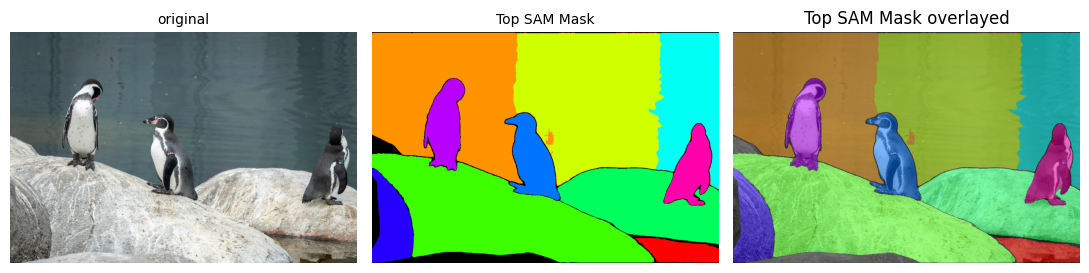


🧠 Ollama Description:
 This image captures a serene night scene at the zoo. The main focus is on three black birds, perched confidently on rocks near the water's edge. One bird stands out with its wings spread wide, perhaps ready for flight or simply enjoying the cool breeze. 

The backdrop of this peaceful tableau is a tranquil pond, its surface calm and still. A dock stretches across it, providing a vantage point from which to observe the birds. On either side of the dock, two black birds are visible, their silhouettes stark against the moonlit sky. 

The photo has been edited with a color palette that is mostly dark, giving it a striking contrast. This effect enhances the night-time ambiance and makes the birds stand out even more. The overall composition of the image suggests a quiet moment in nature, captured at the right time. 


In [1]:
#!pip install segment-anything-py
# ollama serve
# ollama pull llava
# https://github.com/facebookresearch/segment-anything?tab=readme-ov-file#model-checkpoints
%matplotlib inline
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import base64
import requests

# -----------------------------
# 1️⃣ FORCE GPU + VERIFY
# -----------------------------
assert torch.cuda.is_available(), "CUDA not available. Install GPU PyTorch."

device = torch.device("cuda")
print("Using GPU:", torch.cuda.get_device_name(0))

# Enable cudnn autotuner
torch.backends.cudnn.benchmark = True

# -----------------------------
# 2️⃣ Load SAM (FP16 + eval)
# -----------------------------
sam_checkpoint = "models/sam_vit_h_4b8939.pth"
model_type = "vit_h"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device)
sam.eval()

# Use mixed precision
sam = sam.half()

# -----------------------------
# 3️⃣ Optimized Mask Generator
# -----------------------------
mask_generator = SamAutomaticMaskGenerator(
    sam,
    points_per_side=16,          # ↓ default 32 → 4x faster
    pred_iou_thresh=0.88,
    stability_score_thresh=0.92,
    crop_n_layers=1,             # ↓ reduce pyramid crops
    min_mask_region_area=100
)

# -----------------------------
# 4️⃣ Load + Resize Image
# -----------------------------
image_path = "images/penguins.jpg"
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize large images (critical for speed)
max_size = 1024
h, w = image_rgb.shape[:2]
scale = max_size / max(h, w)

if scale < 1:
    image_rgb = cv2.resize(image_rgb, (int(w * scale), int(h * scale)))

# -----------------------------
# 5️⃣ Generate Masks (NO GRAD)
# -----------------------------
with torch.no_grad():
    with torch.cuda.amp.autocast():
        masks = mask_generator.generate(image_rgb)

print(f"Total masks detected: {len(masks)}")

# -----------------------------
# 6️⃣ Postprocess
# -----------------------------
masks = sorted(masks, key=lambda x: x['area'], reverse=True)
top_mask = masks[0]['segmentation']
# Create SAM 1 Visualization
sam1_mask_viz = np.zeros_like(image_rgb)
if masks:
    # Sort by area and take top masks for a vibrant look
    sorted_masks = sorted(masks, key=(lambda x: x['area']), reverse=True)
    for i, ann in enumerate(sorted_masks[:10]): # Top 10 objects
        m = ann['segmentation']
        color = (np.array(plt.cm.hsv(i / 10)[:3]) * 255).astype(np.uint8)
        sam1_mask_viz[m] = color
# -----------------------------
# 7️⃣ Visualization
# -----------------------------
plt.figure(figsize=(11,6))
plt.subplot(131), plt.imshow(image_rgb), plt.axis('off'), plt.title('original', size=10)
plt.subplot(132), plt.imshow(sam1_mask_viz), plt.axis('off'), plt.title('Top SAM Mask', size=10) # top_mask
plt.subplot(133), plt.imshow(image_rgb), plt.imshow(sam1_mask_viz, alpha=0.5), plt.axis('off'), plt.title('original', size=10),
plt.title("Top SAM Mask overlayed")
plt.tight_layout()
plt.show()

# -----------------------------
# 5️⃣ Extract Object Crop
# -----------------------------
mask = top_mask.astype(np.uint8)
object_crop = image_rgb * mask[..., None]

crop_path = "images/object_crop.jpg"
cv2.imwrite(crop_path, cv2.cvtColor(object_crop, cv2.COLOR_RGB2BGR))

# -----------------------------
# 6️⃣ Send to Ollama (LLaVA)
# -----------------------------
# !ollama pull llava
with open(crop_path, "rb") as f:
    img_base64 = base64.b64encode(f.read()).decode("utf-8")

response = requests.post(
    "http://localhost:11434/api/generate",
    json={
        "model": "llava",
        "prompt": "Describe this segmented object in detail.",
        "images": [img_base64],
        "stream": False
    }
)

print("\n🧠 Ollama Description:")
print(response.json()["response"])

You can use **SAM 2** as a **high-precision refinement engine** that takes the rough bounding boxes found by other tools (e.g., **SAM**) and converts them into pixel-perfect, object-specific segmentation masks, as shown in the next animation.

![](images/sam.gif)

#### 4.2 MaskCLIP

C:\Users\sandi\anaconda3\envs\torch-gpu\Lib\site-packages\transformers\image_processing_base.py:370: UserWarning: The following named arguments are not valid for `Mask2FormerImageProcessor.__init__` and were ignored: '_max_size', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


Loading weights:   0%|          | 0/782 [00:00<?, ?it/s]

`label_ids_to_fuse` unset. No instance will be fused.


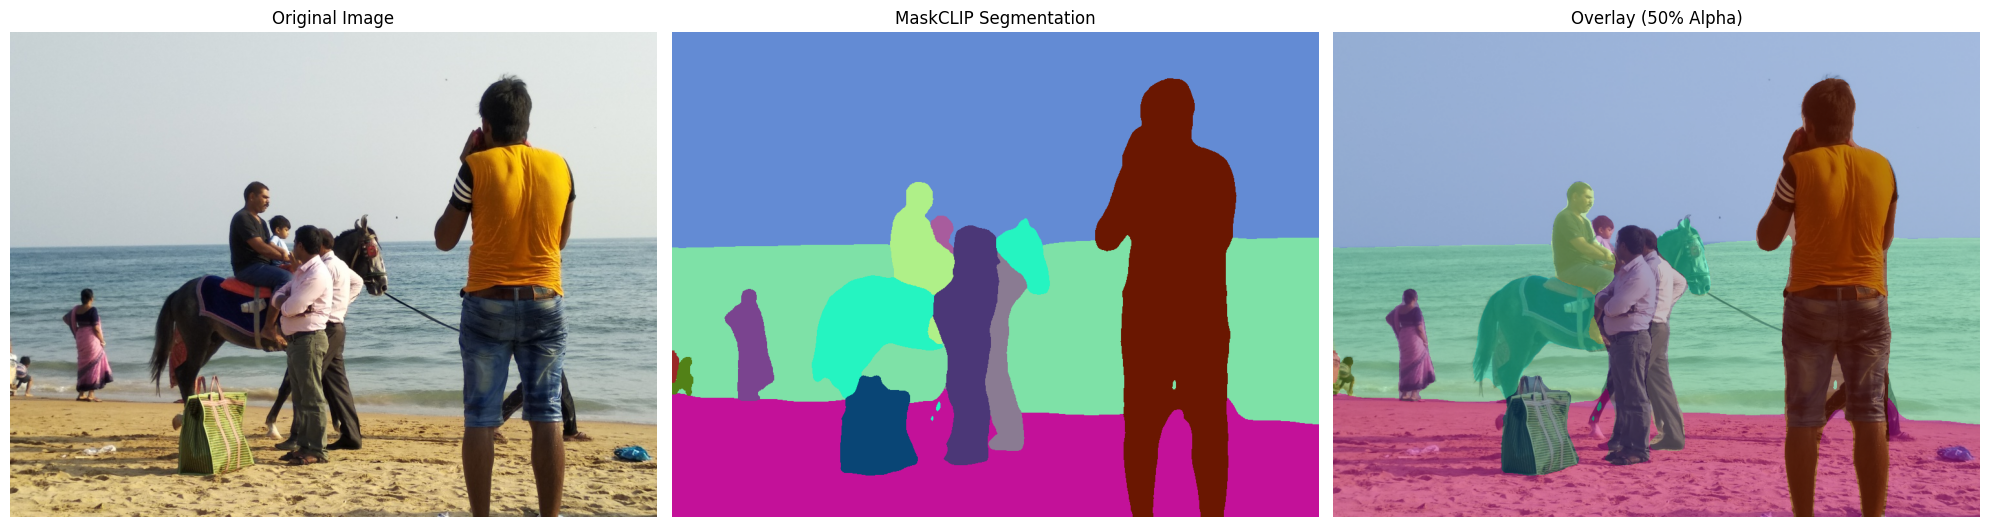

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from transformers import Mask2FormerImageProcessor, Mask2FormerForUniversalSegmentation

# 1. Setup Device and Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = Mask2FormerImageProcessor.from_pretrained("facebook/mask2former-swin-large-coco-panoptic")
model = Mask2FormerForUniversalSegmentation.from_pretrained("facebook/mask2former-swin-large-coco-panoptic").to(device)

# 2. Process Image
image = Image.open("images/men_beach2.jpg").convert("RGB")
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

# 3. Post-Process
target_size = [image.size[::-1]] # (height, width)
result = processor.post_process_panoptic_segmentation(outputs, target_sizes=target_size)[0]
segmentation = result["segmentation"].cpu().numpy()

# 4. Colorize the Segmentation Map
def get_vibrant_mask(seg_map):
    h, w = seg_map.shape
    color_img = np.zeros((h, w, 3), dtype=np.uint8)
    unique_ids = np.unique(seg_map)
    np.random.seed(11)
    for uid in unique_ids:
        if uid == -1: continue # Skip void
        # Generate a vibrant color based on ID
        np.random.seed(uid)
        color = np.random.randint(0, 255, (3,), dtype=np.uint8)
        color_img[seg_map == uid] = color
    return color_img

seg_color = get_vibrant_mask(segmentation)

# 5. Create Overlay
image_np = np.array(image)
overlay = (image_np * 0.5 + seg_color * 0.5).astype(np.uint8)

# 6. Plot Side-by-Side
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

axes[0].imshow(image_np)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(seg_color)
axes[1].set_title("MaskCLIP Segmentation")
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title("Overlay (50% Alpha)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### **5. Text-Guided Semantic Segmentation with Vision–Language Models**

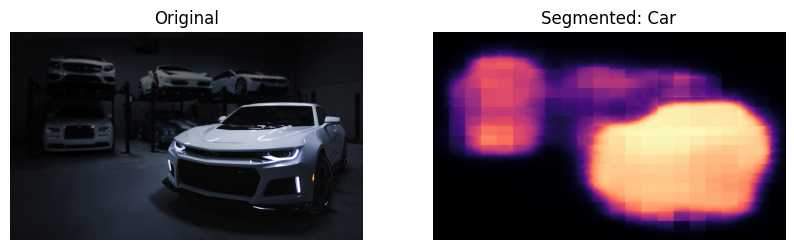

In [10]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
import requests
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load pretrained segmentation model
processor = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
model = CLIPSegForImageSegmentation.from_pretrained(
    "CIDAS/clipseg-rd64-refined"
).to(device)

# Load image
url = "https://images.unsplash.com/photo-1492144534655-ae79c964c9d7"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

# Define what you want to segment
prompt = "car"

# Preprocess
inputs = processor(text=prompt, images=image, return_tensors="pt").to(device)

# Inference
with torch.no_grad():
    outputs = model(**inputs)

mask = outputs.logits.unsqueeze(1)
mask = torch.sigmoid(mask)

# Resize to original
mask = torch.nn.functional.interpolate(
    mask,
    size=image.size[::-1],
    mode="bilinear",
    align_corners=False,
)

mask_np = mask[0, 0].cpu().numpy()

# Visualization
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_np, cmap="magma")
plt.title("Segmented: Car")
plt.axis("off")

plt.show()

#### **A Gradio App**

In [ ]:
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

clipseg_processor = CLIPSegProcessor.from_pretrained(
    "CIDAS/clipseg-rd64-refined"
)
clipseg_model = CLIPSegForImageSegmentation.from_pretrained(
    "CIDAS/clipseg-rd64-refined"
).to(device)

import numpy as np
import cv2

def segment_with_clipseg(image_pil, text):
    """
    True semantic segmentation (text → mask)
    No boxes, no SAM.
    """

    inputs = clipseg_processor(
        text=[text],
        images=[image_pil],
        padding=True,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = clipseg_model(**inputs)

    # logits → mask
    logits = outputs.logits[0]   # (H, W)
    mask = torch.sigmoid(logits).cpu().numpy()

    # Resize to original image
    mask = cv2.resize(
        mask,
        (image_pil.size[0], image_pil.size[1])
    )

    # Threshold
    mask = (mask > 0.5).astype(np.uint8) * 255

    return mask

def create_overlay(image_np, mask):
    import cv2

    overlay = image_np.copy()
    overlay[mask > 0] = [255, 0, 0]

    return cv2.addWeighted(image_np, 0.7, overlay, 0.3, 0)

def process(image, text):
    image_pil = image.convert("RGB")
    image_np = np.array(image_pil)

    # Direct segmentation
    mask = segment_with_clipseg(image_pil, text)

    overlay = create_overlay(image_np, mask)

    return mask, overlay

import gradio as gr

demo = gr.Interface(
    fn=process,
    inputs=[
        gr.Image(type="pil"),
        gr.Textbox(label="Text Prompt")
    ],
    outputs=[
        gr.Image(label="Mask"),
        gr.Image(label="Overlay")
    ],
    title="⚡ Text-to-Semantic Segmentation (CLIPSeg)"
)

demo.launch()

![](images/clipseg.gif)

### **6. Depth Estimation and 3D Scene Understanding from a Single Image**

#### **6.1 From Image to Depth: Monocular Depth Estimation**

Loading weights:   0%|          | 0/458 [00:00<?, ?it/s]

DPTForDepthEstimation LOAD REPORT from: Intel/dpt-large
Key                                                            | Status  | 
---------------------------------------------------------------+---------+-
neck.fusion_stage.layers.0.residual_layer1.convolution1.weight | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution1.bias   | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution2.bias   | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution2.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


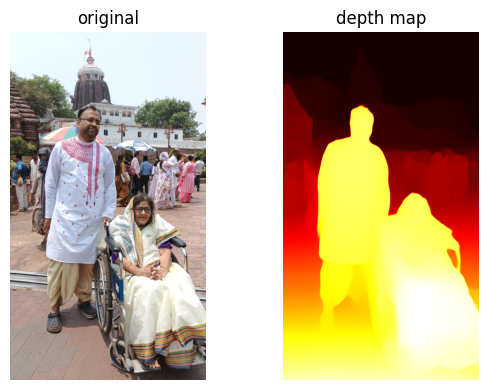

In [2]:
# run in colab
# !pip install open3d
# !pip install plotly
import torch
import cv2
import numpy as np
from transformers import DPTImageProcessor, DPTForDepthEstimation

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = DPTImageProcessor.from_pretrained("Intel/dpt-large")
model = DPTForDepthEstimation.from_pretrained("Intel/dpt-large").to(device)
model.eval()

def get_depth(image):
    # Ensure inputs go to same device as model
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}  # 🔥 FIX

    with torch.no_grad():
        outputs = model(**inputs)
        depth = outputs.predicted_depth

    depth = torch.nn.functional.interpolate(
        depth.unsqueeze(1),
        size=image.shape[:2],
        mode="bicubic",
        align_corners=False,
    ).squeeze().cpu().numpy()  # move back to CPU for numpy

    depth = (depth - depth.min()) / (depth.max() - depth.min() + 1e-8)
    return depth

import matplotlib.pylab as plt
img = cv2.imread('images/we_puri.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
depth = get_depth(img_rgb)
plt.figure(figsize=(6, 4))
plt.subplot(121), plt.imshow(img_rgb), plt.title('original'), plt.axis('off')
plt.subplot(122), plt.imshow(depth, cmap='hot'), plt.title('depth map'), plt.axis('off')
plt.tight_layout()
plt.show()

#### **6.2 Point Cloud Generation and 3D Reconstruction**

In [ ]:
import open3d as o3d
import plotly.graph_objects as go

def depth_to_pointcloud(color, depth):
    h, w = depth.shape

    # Camera intrinsics (approximate)
    fx = fy = 500
    cx = w / 2
    cy = h / 2

    points = []
    colors = []

    for y in range(h):
        for x in range(w):
            z = depth[y, x]
            if z <= 0: continue

            X = (x - cx) * z / fx
            Y = (y - cy) * z / fy

            points.append([X, Y, z])
            colors.append(color[y, x] / 255.0)

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(np.array(points))
    pcd.colors = o3d.utility.Vector3dVector(np.array(colors))

    return pcd

def fuse_pointclouds(pcd_list):
    combined = o3d.geometry.PointCloud()
    for pcd in pcd_list:
        combined += pcd

    combined = combined.voxel_down_sample(voxel_size=0.01)
    combined.estimate_normals()

    return combined
    
image_paths = ["we_puri1.jpeg", "we_puri2.jpeg", "we_puri3.jpeg"]  # multiple views

#from glob import glob
#image_paths = glob('vic_*.jpg')
#image_paths

pcds = []

for path in image_paths:
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    depth = get_depth(img_rgb)

    pcd = depth_to_pointcloud(img_rgb, depth)
    pcds.append(pcd)

# Fuse
final_pcd = fuse_pointclouds(pcds)

def draw_geometries(geometries):
    graph_objects = []

    for geometry in geometries:
        geometry_type = geometry.get_geometry_type()

        if geometry_type == o3d.geometry.Geometry.Type.PointCloud:
            points = np.asarray(geometry.points)
            colors = None
            if geometry.has_colors():
                colors = np.asarray(geometry.colors)
            elif geometry.has_normals():
                colors = (0.5, 0.5, 0.5) + np.asarray(geometry.normals) * 0.5
            else:
                geometry.paint_uniform_color((1.0, 0.0, 0.0))
                colors = np.asarray(geometry.colors)

            scatter_3d = go.Scatter3d(x=points[:,0], y=points[:,1], z=points[:,2], mode='markers', marker=dict(size=1, color=colors))
            graph_objects.append(scatter_3d)

        if geometry_type == o3d.geometry.Geometry.Type.TriangleMesh:
            triangles = np.asarray(geometry.triangles)
            vertices = np.asarray(geometry.vertices)
            colors = None
            if geometry.has_triangle_normals():
                colors = (0.5, 0.5, 0.5) + np.asarray(geometry.triangle_normals) * 0.5
                colors = tuple(map(tuple, colors))
            else:
                colors = (1.0, 0.0, 0.0)

            mesh_3d = go.Mesh3d(x=vertices[:,0], y=vertices[:,1], z=vertices[:,2], i=triangles[:,0], j=triangles[:,1], k=triangles[:,2], facecolor=colors, opacity=0.50)
            graph_objects.append(mesh_3d)

    fig = go.Figure(
        data=graph_objects,
        layout=dict(
            scene=dict(
                xaxis=dict(visible=False),
                yaxis=dict(visible=False),
                zaxis=dict(visible=False)
            )
        )
    )
    fig.show()

# Visualize
o3d.visualization.draw_geometries = draw_geometries # replace function
o3d.visualization.draw_geometries([final_pcd])

![](images/sfm_open3d_out.png)
![](images/sfm_open3d_out2.png)

### **6.3 Semantic 3D Fusion**

In [ ]:
from transformers import AutoImageProcessor, AutoModelForSemanticSegmentation
import plotly.graph_objects as go

seg_processor = AutoImageProcessor.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512"
)

seg_model = AutoModelForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512"
).to(device)
seg_model.eval()

def get_segmentation(image):
    inputs = seg_processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = seg_model(**inputs)

    logits = torch.nn.functional.interpolate(
        outputs.logits,
        size=image.shape[:2],
        mode="bilinear",
        align_corners=False
    )

    seg = logits.argmax(dim=1)[0].cpu().numpy()
    return seg

def depth_seg_to_pointcloud(color, depth, seg):

    h, w = depth.shape
    print(np.unique(seg))

    fx = fy = 500
    cx = w / 2
    cy = h / 2

    # random color map per class
    np.random.seed(0)
    cmap = np.random.randint(0, 255, (256, 3))

    points = []
    colors = []

    for y in range(h):
        for x in range(w):
            z = depth[y, x]
            if z <= 0:
                continue

            X = (x - cx) * z / fx
            Y = (y - cy) * z / fy

            label = seg[y, x]
            #print(color[y,x], label, cmap[label])
            color_val = cmap[label] / 255.0
            #print(color_val)
            points.append([X, Y, z])
            colors.append(color_val)

    import open3d as o3d
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(np.array(points))
    pcd.colors = o3d.utility.Vector3dVector(np.array(colors))

    return pcd, points, colors

img = cv2.imread('cats.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

depth = get_depth(img_rgb)
seg = get_segmentation(img_rgb)

pcd_semantic, points, colors = depth_seg_to_pointcloud(img_rgb, depth, seg)
pcd_semantic = pcd_semantic.translate(-pcd_semantic.get_center())
o3d.visualization.draw_plotly([pcd_semantic])

![](images/semantic_3d_fusion.png)

### **7. Practical Applications**
#### **7.1 Blurring Background with DeepLabV3, MediaPipe and tflite**

In [ ]:
#run in colab
#!pip install gradio mediapipe
#!wget -O deeplabv3.tflite -q https://storage.googleapis.com/mediapipe-models/image_segmenter/deeplab_v3/float32/1/deeplab_v3.tflite
import gradio as gr
import numpy as np
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Load DeepLabV3 TFLite once
base_options = python.BaseOptions(model_asset_path="deeplabv3.tflite")
options = vision.ImageSegmenterOptions(
    base_options=base_options,
    output_category_mask=True
)
segmenter = vision.ImageSegmenter.create_from_options(options)

def segment_and_blur(img):
    # Convert numpy image to MediaPipe Image
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img)
    result = segmenter.segment(mp_image)
    mask = result.category_mask.numpy_view().squeeze()

    # Binary mask
    binary_mask = (mask > 0.2).astype(np.uint8) * 255
    binary_mask_rgb = np.stack([binary_mask]*3, axis=-1)

    # Blur background
    blurred = cv2.GaussianBlur(img, (55, 55), 0)
    condition = mask > 0.1
    final = np.where(condition[..., None], img, blurred)

    return img, binary_mask_rgb, final

with gr.Blocks() as demo:
    gr.Markdown("## DeepLabV3 Background Blur (TFLite + MediaPipe)")
    with gr.Row():
        input_img = gr.Image(type="numpy", label="Upload Image")
    with gr.Row():
        out1 = gr.Image(label="Original")
        out2 = gr.Image(label="Binary Segmentation")
        out3 = gr.Image(label="Background Blurred")

    input_img.change(segment_and_blur, input_img, [out1, out2, out3])

demo.launch()

![](images/gradio_bblur.png)

#### **6.2 Segmentation wit hDetectron2**

In [ ]:
# run in colab
# install Detectron2
# !python -m pip install 'git+https://github.com/facebookresearch/detectron2.git'
# import detectron2
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load image
image_path = "dogs_cats.jpg"
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# =====================================================
# 1️⃣ INSTANCE SEGMENTATION (Mask R-CNN)
# =====================================================
cfg_ins = get_cfg()
cfg_ins.merge_from_file(
    model_zoo.get_config_file(
        "COCO-InstanceSegmentation/mask_rcnn_R_101_FPN_3x.yaml"
    )
)
cfg_ins.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    "COCO-InstanceSegmentation/mask_rcnn_R_101_FPN_3x.yaml"
)
cfg_ins.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg_ins.MODEL.DEVICE = device

predictor_ins = DefaultPredictor(cfg_ins)
outputs_ins = predictor_ins(image)

v_ins = Visualizer(
    image_rgb,
    MetadataCatalog.get(cfg_ins.DATASETS.TRAIN[0]),
    scale=1.2
)

ins_result = v_ins.draw_instance_predictions(
    outputs_ins["instances"].to("cpu")
)

# =====================================================
# 2️⃣ PANOPTIC SEGMENTATION
# =====================================================
cfg_pan = get_cfg()
cfg_pan.merge_from_file(
    model_zoo.get_config_file(
        "COCO-PanopticSegmentation/panoptic_fpn_R_101_3x.yaml"
    )
)
cfg_pan.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    "COCO-PanopticSegmentation/panoptic_fpn_R_101_3x.yaml"
)
cfg_pan.MODEL.DEVICE = device

predictor_pan = DefaultPredictor(cfg_pan)
panoptic_seg, segments_info = predictor_pan(image)["panoptic_seg"]

metadata = MetadataCatalog.get(cfg_pan.DATASETS.TRAIN[0])

# --- assign bright distinct colors ---
import random

# modify existing colors instead of reassigning
for i in range(len(metadata.thing_colors)):
    metadata.thing_colors[i] = [
        random.randint(0,150),
        random.randint(0,150),
        random.randint(0,150)
    ]

v_pan = Visualizer(image_rgb, metadata, scale=1.2)
pan_result = v_pan.draw_panoptic_seg_predictions(
    panoptic_seg.to("cpu"),
    segments_info
)

# =====================================================
# 3️⃣ SEMANTIC FROM PANOPTIC
# =====================================================
panoptic_np = panoptic_seg.to("cpu").numpy()

semantic_map = np.zeros_like(panoptic_np)

for segment in segments_info:
    semantic_map[panoptic_np == segment["id"]] = segment["category_id"]

v_sem = Visualizer(
    image_rgb,
    metadata,
    scale=1.2,
    instance_mode=ColorMode.SEGMENTATION
)

sem_result = v_sem.draw_sem_seg(
    torch.tensor(semantic_map)
)

# =====================================================
# 4️⃣ Visualization
# =====================================================
plt.figure(figsize=(22,7))

plt.subplot(1,4,1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(sem_result.get_image())
plt.title("Semantic (from Panoptic)")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(ins_result.get_image())
plt.title("Instance (Mask R-CNN)")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(pan_result.get_image())
plt.title("Panoptic FPN")
plt.axis("off")

plt.tight_layout()
plt.show()

![](images/dogs_cats_out.png)

### **7. Training Your Own Segmentation Model**

#### **7.1 with UNet using `keras` function API**

In [ ]:
# run in colab
#!pip install kaggle
import kagglehub
import os 

# download dataset
os.environ["KAGGLEHUB_CACHE"] = "/content/"

# Download latest version
path = kagglehub.dataset_download("kumaresanmanickavelu/lyft-udacity-challenge") 
print("Path to dataset files:", path)

!mkdir lyft-udacity-challenge
!mv datasets/kumaresanmanickavelu/lyft-udacity-challenge/versions/1/* lyft-udacity-challenge

In [ ]:
# https://www.kaggle.com/ghrangel/u-net-list-semantic-cars-acc-96
import imageio
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Conv2DTranspose, concatenate
from glob import glob

train_image_list = sorted(glob('lyft-udacity-challenge/dataA/dataA/CameraRGB/*.png'))
train_mask_list = sorted(glob('lyft-udacity-challenge/dataA/dataA/CameraSeg/*.png'))
test_image_list = sorted(glob('lyft-udacity-challenge/dataa/dataA/CameraRGB/*.png'))
test_mask_list = sorted(glob('lyft-udacity-challenge/dataa/dataA/CameraSeg/*.png'))

img, mask = imageio.imread(train_image_list[0]), imageio.imread(train_mask_list[0])
#print(img.shape, mask.shape)
mask = np.array([max(mask[i, j]) for i in range(mask.shape[0]) for j in range(mask.shape[1])]).reshape(img.shape[0], img.shape[1])

def labels_to_cityscapes_palette(image):
    """
    Convert an image containing CARLA semantic segmentation labels to
    Cityscapes palette.
    """
    classes = {
        0: [0, 0, 0],        # None
        1: [70, 70, 70],     # Buildings
        2: [190, 153, 153],  # Fences
        3: [72, 0, 90],      # Other
        4: [220, 20, 60],    # Pedestrians
        5: [153, 153, 153],  # Poles
        6: [157, 234, 50],   # RoadLines
        7: [128, 64, 128],   # Roads
        8: [244, 35, 232],   # Sidewalks
        9: [107, 142, 35],   # Vegetation
        10: [0, 0, 255],     # Vehicles
        11: [102, 102, 156], # Walls
        12: [220, 220, 0]    # TrafficSigns
    }
    array = np.asarray(image) #labels_to_array(image)
    result = np.zeros((array.shape[0], array.shape[1], 3)).astype(np.uint8)
    for key, value in classes.items():
        result[np.where(array == key)] = value
    return result

# now let's plot
fig, ax  = plt.subplots(1,2,figsize=(9,4))
ax[0].imshow(img), ax[0].set_title('Original Image'), ax[0].axis('off')
ax[1].imshow(labels_to_cityscapes_palette(mask)), ax[1].set_title('Mask'), ax[1].axis('off')
plt.tight_layout()

![](images/udacity_data_plot.png)

In [10]:
train_image_list_dataset = tf.data.Dataset.list_files(train_image_list ,shuffle=False)
train_mask_list_dataset = tf.data.Dataset.list_files(train_mask_list , shuffle=False)
train_images_filenames = tf.constant(train_image_list)
train_masks_filenames = tf.constant(train_mask_list)

test_image_list_dataset = tf.data.Dataset.list_files(test_image_list ,shuffle=False)
test_mask_list_dataset = tf.data.Dataset.list_files(test_mask_list , shuffle=False)
test_images_filenames = tf.constant(test_image_list)
test_masks_filenames = tf.constant(test_mask_list)

train_dataset = tf.data.Dataset.from_tensor_slices((train_images_filenames, train_masks_filenames))
test_dataset = tf.data.Dataset.from_tensor_slices((test_images_filenames, test_masks_filenames))

def process_path(image_path,mask_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img,channels=3)
    #this do the same as dividing by 255 to set the values between 0 and 1 (normalization)
    img = tf.image.convert_image_dtype(img,tf.float32)
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask,channels=3)
    mask = tf.math.reduce_max(mask,axis=-1,keepdims=True)
    return img , mask

def preprocess(image,mask) :
    input_image = tf.image.resize(image,(96,128),method='nearest')
    input_mask = tf.image.resize(mask,(96,128),method='nearest')
    return input_image, input_mask

train_image_ds = train_dataset.map(process_path) # apply the preprocces_path function to our dataset
processed_train_image_ds = train_image_ds.map(preprocess) # apply the preprocess function to our dataset
test_image_ds = test_dataset.map(process_path) # apply the preprocces_path function to our dataset
processed_test_image_ds = test_image_ds.map(preprocess) # apply the preprocess function to our dataset

In [18]:
def conv_block(inputs=None, n_filters=32, dropout_prob=0, max_pooling=True):

    conv = Conv2D(n_filters,
                  kernel_size = 3,
                  activation='relu',
                  padding='same',
                  kernel_initializer=tf.keras.initializers.HeNormal())(inputs)
    conv = Conv2D(n_filters,
                  kernel_size = 3,
                  activation='relu',
                  padding='same',
                  kernel_initializer=tf.keras.initializers.HeNormal())(conv)

    if dropout_prob > 0:
        conv = Dropout(dropout_prob)(conv)
        
    next_layer = MaxPooling2D(pool_size=(2,2))(conv) if max_pooling else conv
    skip_connection = conv

    return next_layer, skip_connection

def upsampling_block(expansive_input, contractive_input, n_filters=32):

    up = Conv2DTranspose(
                 n_filters,
                 kernel_size = 3,
                 strides=(2,2),
                 padding='same')(expansive_input)

    merge = concatenate([up, contractive_input], axis=3)
    conv = Conv2D(n_filters,
                 kernel_size = 3,
                 activation='relu',
                 padding='same',
                 kernel_initializer=tf.keras.initializers.HeNormal())(merge)
    conv = Conv2D(n_filters,
                 kernel_size = 3,
                 activation='relu',
                 padding='same',
                 kernel_initializer=tf.keras.initializers.HeNormal())(conv)
    return conv

def unet_model(input_size=(96, 128, 3), n_filters=32, n_classes=23):

    inputs = Input(input_size)

    #contracting path
    cblock1 = conv_block(inputs, n_filters)
    cblock2 = conv_block(cblock1[0], 2*n_filters)
    cblock3 = conv_block(cblock2[0], 4*n_filters)
    cblock4 = conv_block(cblock3[0], 8*n_filters, dropout_prob=0.3)
    cblock5 = conv_block(cblock4[0],16*n_filters, dropout_prob=0.3, max_pooling=None)

    #expanding path
    ublock6 = upsampling_block(cblock5[0], cblock4[1],  8 * n_filters)
    ublock7 = upsampling_block(ublock6, cblock3[1],  n_filters*4)
    ublock8 = upsampling_block(ublock7,cblock2[1] , n_filters*2)
    ublock9 = upsampling_block(ublock8,cblock1[1],  n_filters)

    conv9 = Conv2D(n_filters, 3,
                 activation='relu',
                 padding='same',
                 kernel_initializer='he_normal')(ublock9)

    conv10 = Conv2D(n_classes, kernel_size=1, padding='same')(conv9)
    model = tf.keras.Model(inputs=inputs, outputs=conv10)

    return model

img_height = 96
img_width = 128
num_channels = 3

unet = unet_model((img_height, img_width, num_channels))
unet.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 128,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 96, 128,   │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 96, 128,   │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 48, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 48, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 48, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 24, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 24, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 24, 32,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 12, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 12, 16,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 12, 16,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 12, 16,    │          0 │ conv2d_7[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 6, 8, 256) │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 6, 8, 512) │  1,180,160 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 6, 8, 512) │  2,359,808 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 6, 8, 512) │          0 │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 12, 16,    │  1,179,904 │ dropout_1[0][0] 

 Total params: 8,640,471 (32.96 MB)

 Trainable params: 8,640,471 (32.96 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
NUM_CLASSES = 23
EPOCHS = 25
VAL_SUBSPLITS = 5
BUFFER_SIZE = 500
BATCH_SIZE = 16

@tf.keras.utils.register_keras_serializable()
class MeanIoUWrapper(tf.keras.metrics.MeanIoU):
    def __init__(self, num_classes, name="mean_iou", **kwargs):
        super().__init__(num_classes=num_classes, name=name, **kwargs)

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.argmax(y_pred, axis=-1)
        y_true = tf.squeeze(tf.cast(y_true, tf.int32), axis=-1)
        return super().update_state(y_true, y_pred, sample_weight)

miou_metric = MeanIoUWrapper(NUM_CLASSES)
unet.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy', miou_metric]
)

processed_train_image_ds.batch(BATCH_SIZE)
train_dataset = processed_train_image_ds.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
model_history = unet.fit(train_dataset, epochs=EPOCHS)

(TensorSpec(shape=(96, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(96, 128, 1), dtype=tf.uint8, name=None))
Epoch 1/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 65s 480ms/step - accuracy: 0.3421 - loss: 2.2086 - mean_iou: 0.0528
Epoch 2/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.7917 - loss: 0.6192 - mean_iou: 0.2872
Epoch 3/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.8446 - loss: 0.4852 - mean_iou: 0.3363
Epoch 4/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.8809 - loss: 0.3796 - mean_iou: 0.3893
Epoch 5/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.8972 - loss: 0.3322 - mean_iou: 0.4254
Epoch 6/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.9145 - loss: 0.2740 - mean_iou: 0.4620
Epoch 7/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.9221 - loss: 0.2508 - mean_iou: 0.4814
Epoch 8/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.9265 - loss: 0.2346 - mean_iou: 0.4870
Epoch 9/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms

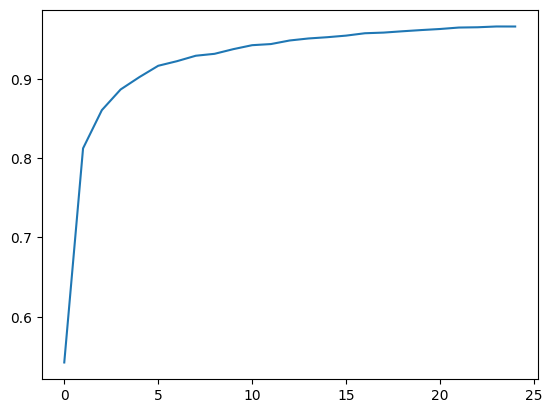

In [22]:
plt.plot(model_history.history["accuracy"])

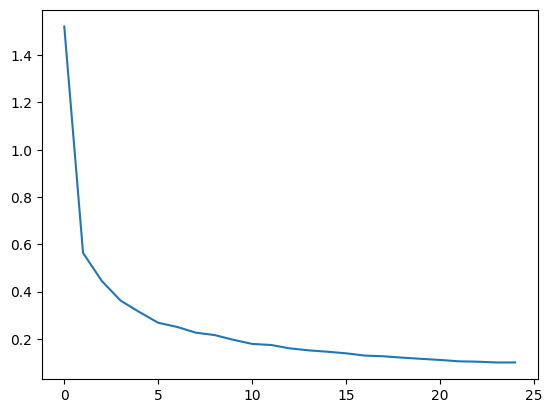

In [23]:
plt.plot(model_history.history["loss"]) #plt.plot(model_history.history["mean_iou"])

In [25]:
# save model
model_json = unet.to_json()
with open("unet_model.json", "w") as json_file:
    json_file.write(model_json)
unet.save_weights("model_30.weights.h5")

# load model structure
json_file = open('unet_model.json', 'r')
loaded_model_json = json_file.read()
json_file.close()

# load model weights
from tensorflow.keras.models import model_from_json
unet1 = model_from_json(
    loaded_model_json,
    custom_objects={"MeanIoUWrapper": MeanIoUWrapper}
)
unet1.load_weights("model_30.weights.h5")

In [27]:
def display(display_list):
    plt.figure(figsize=(15, 5))
    plt.subplots_adjust(0,0,1,0.95,0.05, 0.05)
    title = ['Input Image', 'True Mask', 'Predicted Mask']
    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i+1)
        plt.title(title[i], size=15)
        img = np.squeeze(display_list[i]) #tf.keras.preprocessing.image.array_to_img(display_list[i])
        if i > 0:
          img = labels_to_cityscapes_palette(img).astype(np.uint8)
        plt.imshow(img)
        plt.axis('off')
    plt.suptitle('Semantic Segmentation with U-Net trained for 30 epochs', size=20)
    plt.show()
    
def create_mask(pred_mask):
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    return pred_mask[0]

# https://arijitray1993.github.io/CARLA_tutorial/
def show_predictions(dataset=None, num=1):
    """
    Displays the first image of each of the num batches
    """
    if dataset:
        for image, mask in dataset.take(num):
            pred_mask = unet1.predict(image)
            display([image[0], mask[0], create_mask(pred_mask)])
    else:
        display([sample_image, sample_mask,
             create_mask(unet1.predict(sample_image[tf.newaxis, ...]))])

processed_test_image_ds.batch(1)
test_dataset = processed_test_image_ds.cache().shuffle(BUFFER_SIZE).batch(1)
show_predictions(test_dataset, 1)

![](images/udacity_data_pred_plot.png)

In [ ]:
# model evaluation
def evaluate_model(model, dataset):
    metric = MeanIoUWrapper(NUM_CLASSES)

    for images, masks in dataset:
        logits = model(images, training=False)
        metric.update_state(masks, logits)

    print("\nMean IoU:", metric.result().numpy())
    return metric

processed_test_image_ds.batch(1)
test_dataset = processed_test_image_ds.cache().shuffle(BUFFER_SIZE).batch(1)
miou_metric_obj = evaluate_model(unet1, test_dataset)
miou_metric_obj
# Mean IoU: 0.69191945

#### **7.2 U-Net with ResNet18 Backbone with `segmentation_models_pytorch`**

In [23]:
#!pip install segmentation_models_pytorch
#!pip install torchmetrics
import glob
import numpy as np
import imageio
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

from torchmetrics.classification import MulticlassAccuracy, MulticlassJaccardIndex, MulticlassF1Score
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings

# ===============================
# CONFIG
# ===============================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_CLASSES = 13
IMG_HEIGHT = 96
IMG_WIDTH = 128
BATCH_SIZE = 16
EPOCHS = 25
LR = 1e-3

# ===============================
# DATA PATHS
# ===============================
train_images = sorted(glob.glob("lyft-udacity-challenge/dataA/dataA/CameraRGB/*.png"))
train_masks  = sorted(glob.glob("lyft-udacity-challenge/dataA/dataA/CameraSeg/*.png"))

test_images = sorted(glob.glob("lyft-udacity-challenge/dataa/dataA/CameraRGB/*.png"))
test_masks  = sorted(glob.glob("lyft-udacity-challenge/dataa/dataA/CameraSeg/*.png"))

Epoch 1/25: 100%|██████████| 63/63 [00:39<00:00,  1.58it/s]



Epoch [1/25]
Loss        : 1.0050
Accuracy    : 0.3375
Mean IoU    : 0.2702
Mean Dice   : 0.3284



Epoch 2/25: 100%|██████████| 63/63 [00:36<00:00,  1.73it/s]



Epoch [2/25]
Loss        : 0.4323
Accuracy    : 0.4150
Mean IoU    : 0.3571
Mean Dice   : 0.4000



Epoch 3/25: 100%|██████████| 63/63 [00:35<00:00,  1.79it/s]


...


Epoch [24/25]
Loss        : 0.1313
Accuracy    : 0.7307
Mean IoU    : 0.6677
Mean Dice   : 0.7553



Epoch 25/25: 100%|██████████| 63/63 [00:37<00:00,  1.70it/s]



Epoch [25/25]
Loss        : 0.1301
Accuracy    : 0.7326
Mean IoU    : 0.6693
Mean Dice   : 0.7567



Evaluating: 100%|██████████| 63/63 [00:36<00:00,  1.71it/s]


========== FINAL TEST RESULTS ==========
Pixel Accuracy : 0.7218
Mean IoU       : 0.6680
Mean Dice      : 0.7549



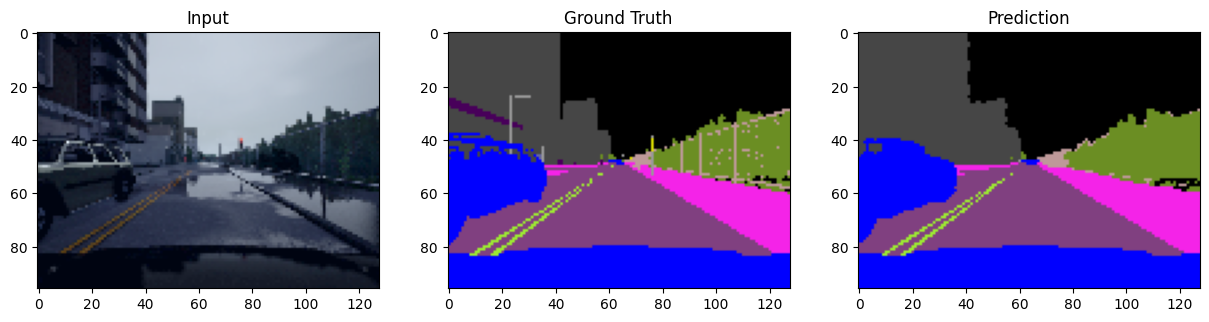

In [24]:
# DATASET
class LyftDataset(Dataset):
    def __init__(self, image_paths, mask_paths):
        self.images = image_paths
        self.masks = mask_paths

        self.transform = A.Compose([
            A.Resize(IMG_HEIGHT, IMG_WIDTH),
            A.Normalize(),
            ToTensorV2()
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = imageio.imread(self.images[idx])
        mask = imageio.imread(self.masks[idx])

        mask = np.max(mask, axis=-1)

        augmented = self.transform(image=image, mask=mask)
        image = augmented["image"]
        mask = augmented["mask"].long()

        return image, mask


train_loader = DataLoader(
    LyftDataset(train_images, train_masks),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    LyftDataset(test_images, test_masks),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# ===============================
# MODEL
# ===============================
model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights=None,
    in_channels=3,
    classes=NUM_CLASSES
).to(DEVICE)

# LOSS & OPTIMIZER
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# ===============================
# TRAIN METRICS (Epoch-wise)
# ===============================
train_acc_metric = MulticlassAccuracy(num_classes=NUM_CLASSES).to(DEVICE)
train_miou_metric = MulticlassJaccardIndex(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
train_dice_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)

# TRAINING LOOP
for epoch in range(EPOCHS):

    model.train()
    epoch_loss = 0.0

    # Reset metrics at start of epoch
    train_acc_metric.reset()
    train_miou_metric.reset()
    train_dice_metric.reset()

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        train_acc_metric.update(preds, masks)
        train_miou_metric.update(preds, masks)
        train_dice_metric.update(preds, masks)

    # Compute epoch metrics
    epoch_loss /= len(train_loader)
    epoch_accuracy = train_acc_metric.compute().item()
    epoch_miou = train_miou_metric.compute().item()
    epoch_dice = train_dice_metric.compute().item()

    print("\n=======================================")
    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(f"Loss        : {epoch_loss:.4f}")
    print(f"Accuracy    : {epoch_accuracy:.4f}")
    print(f"Mean IoU    : {epoch_miou:.4f}")
    print(f"Mean Dice   : {epoch_dice:.4f}")
    print("=======================================\n")

torch.save(model.state_dict(), "unet_smp.pth")

# FINAL EVALUATION
model.eval()

pixel_acc_metric = MulticlassAccuracy(num_classes=NUM_CLASSES).to(DEVICE)
miou_metric = MulticlassJaccardIndex(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
dice_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)

pixel_acc_metric.reset()
miou_metric.reset()
dice_metric.reset()

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Evaluating"):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        pixel_acc_metric.update(preds, masks)
        miou_metric.update(preds, masks)
        dice_metric.update(preds, masks)

print("\n========== FINAL TEST RESULTS ==========")
print(f"Pixel Accuracy : {pixel_acc_metric.compute().item():.4f}")
print(f"Mean IoU       : {miou_metric.compute().item():.4f}")
print(f"Mean Dice      : {dice_metric.compute().item():.4f}")
print("========================================\n")

# ===============================
# VISUALIZATION
# ===============================
def labels_to_cityscapes_palette(mask):
    classes = {
        0: [0, 0, 0],
        1: [70, 70, 70],
        2: [190, 153, 153],
        3: [72, 0, 90],
        4: [220, 20, 60],
        5: [153, 153, 153],
        6: [157, 234, 50],
        7: [128, 64, 128],
        8: [244, 35, 232],
        9: [107, 142, 35],
        10: [0, 0, 255],
        11: [102, 102, 156],
        12: [220, 220, 0],
    }
    h, w = mask.shape
    result = np.zeros((h, w, 3))
    for key, value in classes.items():
        result[mask == key] = value
    return result.astype(np.uint8)

model.eval()
with torch.no_grad():
    images, masks = next(iter(test_loader))
    images = images.to(DEVICE)

    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

image_np = images[0].cpu().permute(1,2,0).numpy()
true_mask = masks[0].cpu().numpy()
pred_mask = preds[0].cpu().numpy()

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow((image_np - image_np.min())/(image_np.max()-image_np.min()))
plt.title("Input")

plt.subplot(1,3,2)
plt.imshow(labels_to_cityscapes_palette(true_mask))
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(labels_to_cityscapes_palette(pred_mask))
plt.title("Prediction")

plt.show()

### **8. Training UNet with `segmentation_models` to Segment Brain Tumor MRI iamges**

In [ ]:
# run in colab
import os
import kagglehub
os.environ["KAGGLEHUB_CACHE"] = "/content/"
# Download latest version
path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")
print(path)

!mkdir /content/data/
!mkdir /content/data/lgg-mri-segmentation/
!mv /content/datasets/mateuszbuda/lgg-mri-segmentation/versions/2/kaggle_3m /content/data/lgg-mri-segmentation/

In [21]:
#!pip install segmentation-models tensorflow

import os, glob
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
from PIL import Image as PILImage

os.environ["SM_FRAMEWORK"] = "tf.keras"   # ← must be set before importing segmentation_models
import segmentation_models as sm

IMG_SIZE    = 256
BATCH_SIZE  = 16
NUM_CLASSES = 1
AUTOTUNE    = tf.data.AUTOTUNE
BACKBONE    = "resnet34"                  # pretrained ImageNet backbone

sm.set_framework("tf.keras")
sm.framework()

images = sorted(glob.glob("/content/data/lgg-mri-segmentation/kaggle_3m/**/*[!_mask].tif", recursive=True))
masks  = sorted(glob.glob("/content/data/lgg-mri-segmentation/kaggle_3m/**/*_mask.tif",    recursive=True))

print(f"Found {len(images)} images and {len(masks)} masks")

Segmentation Models: using `tf.keras` framework.
Found 3929 images and 3929 masks


In [22]:
# Preprocessing function matched to ResNet34 ImageNet stats
preprocess_input = sm.get_preprocessing(BACKBONE)

def load_tif(path, channels=3):
    mode = "RGB" if channels == 3 else "L"
    img  = PILImage.open(path).convert(mode).resize((IMG_SIZE, IMG_SIZE), PILImage.NEAREST)
    return np.array(img, dtype=np.float32)

def load_sample_np(img_path, mask_path):
    img_path  = img_path.decode("utf-8")
    mask_path = mask_path.decode("utf-8")

    # Image: apply backbone-specific preprocessing
    img  = load_tif(img_path, channels=3)                    # (H, W, 3) in [0, 255]
    img  = preprocess_input(img)                             # normalizes for ResNet34

    # Mask: binary float 0.0 or 1.0
    mask = load_tif(mask_path, channels=1)
    mask = (mask > 0).astype(np.float32)[..., np.newaxis]   # (H, W, 1)

    return img.astype(np.float32), mask

def tf_load_sample(img_path, mask_path):
    img, mask = tf.numpy_function(
        func = load_sample_np,
        inp  = [img_path, mask_path],
        Tout = [tf.float32, tf.float32],
    )
    img.set_shape ([IMG_SIZE, IMG_SIZE, 3])
    mask.set_shape([IMG_SIZE, IMG_SIZE, 1])
    return img, mask

# Train / val split 80/20
split   = int(len(images) * 0.8)
ds_full = tf.data.Dataset.from_tensor_slices((images, masks)).shuffle(1000, seed=42)

train_ds = (ds_full.take(split)
                   .map(tf_load_sample, num_parallel_calls=AUTOTUNE)
                   .batch(BATCH_SIZE)
                   .prefetch(AUTOTUNE))
val_ds   = (ds_full.skip(split)
                   .map(tf_load_sample, num_parallel_calls=AUTOTUNE)
                   .batch(BATCH_SIZE)
                   .prefetch(AUTOTUNE))

# Sanity check
imgs_test, masks_test = next(iter(train_ds))
print(f"Image shape : {imgs_test.shape}  range=[{imgs_test.numpy().min():.2f}, {imgs_test.numpy().max():.2f}]")
print(f"Mask  shape : {masks_test.shape} unique={np.unique(masks_test)}")
print(f"Train batches : {len(train_ds)} | Val batches : {len(val_ds)}")

Image shape : (16, 256, 256, 3)  range=[0.00, 253.00]
Mask  shape : (16, 256, 256, 1) unique=[0. 1.]
Train batches : 197 | Val batches : 50


In [23]:
model = sm.Unet(
    backbone_name     = BACKBONE,           # ResNet34 encoder
    encoder_weights   = "imagenet",         # pretrained weights
    input_shape       = (IMG_SIZE, IMG_SIZE, 3),
    classes           = NUM_CLASSES,        # 1 output channel
    activation        = "sigmoid",          # binary output
    encoder_freeze    = False,              # fine-tune entire network
)

model.summary()

85521592/85521592 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ data (InputLayer)   │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_data             │ (None, 256, 256,  │          9 │ data[0][0]        │
│ (BatchNormalizatio… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 262, 262,  │          0 │ bn_data[0][0]     │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv0 (Conv2D)      │ (None, 128, 128,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn0                 │ (None, 128, 128,  │        256 │ conv0[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu0 (Activation)  │ (None, 128, 128,  │          0 │ bn0[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 130, 130,  │          0 │ relu0[0][0]       │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooling0            │ (None, 64, 64,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_bn1    │ (None, 64, 64,    │        256 │ pooling0[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_relu1  │ (None, 64, 64,    │          0 │ stage1_unit1_bn1… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 66, 66,    │          0 │ stage1_unit1_rel… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_conv1  │ (None, 64, 64,    │     36,864 │ zero_padding2d_2… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_bn2    │ (None, 64, 64,    │        256 │ stage1_unit1_con… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_relu2  │ (None, 64, 64,    │          0 │ stage1_unit1_bn2… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 66, 66,    │          0 │ stage1_unit1_rel… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_conv2  │ (None, 64, 64,    │     36,864 │ zero_padding2d_3… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_sc     │ (None, 64, 64,    │      4,096 │ stage1_unit1_rel

 Total params: 24,456,154 (93.29 MB)

 Trainable params: 24,438,804 (93.23 MB)

 Non-trainable params: 17,350 (67.77 KB)

In [24]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-4),
    loss      = sm.losses.BinaryCELoss() + sm.losses.DiceLoss(),   # combined loss
    metrics   = [
        sm.metrics.IOUScore(threshold=0.5, name="iou"),
        sm.metrics.FScore(threshold=0.5,   name="f1"),             # Dice coefficient
    ],
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_unet_brain.keras",
        save_best_only = True,
        monitor        = "val_iou",
        mode           = "max",
        verbose        = 1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor  = "val_loss",
        patience = 3,
        factor   = 0.5,
        min_lr   = 1e-7,
        verbose  = 1,
    ),
    keras.callbacks.EarlyStopping(
        monitor              = "val_iou",
        patience             = 7,
        mode                 = "max",
        restore_best_weights = True,
        verbose              = 1,
    ),
]

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = 30,
    callbacks       = callbacks,
)

Epoch 1/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - f1: 0.2305 - iou: 0.1506 - loss: 1.5601
Epoch 1: val_iou improved from -inf to 0.28673, saving model to best_unet_brain.keras
197/197 ━━━━━━━━━━━━━━━━━━━━ 186s 577ms/step - f1: 0.2312 - iou: 0.1512 - loss: 1.5591 - val_f1: 0.4264 - val_iou: 0.2867 - val_loss: 1.2960 - learning_rate: 1.0000e-04
Epoch 2/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - f1: 0.5639 - iou: 0.4126 - loss: 1.1487
Epoch 2: val_iou improved from 0.28673 to 0.39082, saving model to best_unet_brain.keras
197/197 ━━━━━━━━━━━━━━━━━━━━ 70s 357ms/step - f1: 0.5639 - iou: 0.4126 - loss: 1.1485 - val_f1: 0.5501 - val_iou: 0.3908 - val_loss: 1.0676 - learning_rate: 1.0000e-04
Epoch 3/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - f1: 0.5807 - iou: 0.4286 - loss: 1.0192
Epoch 3: val_iou did not improve from 0.39082
197/197 ━━━━━━━━━━━━━━━━━━━━ 77s 330ms/step - f1: 0.5808 - iou: 0.4287 - loss: 1.0189 - val_f1: 0.3793 - val_iou: 0.2401 - val_loss: 0.9960 - learning_rat

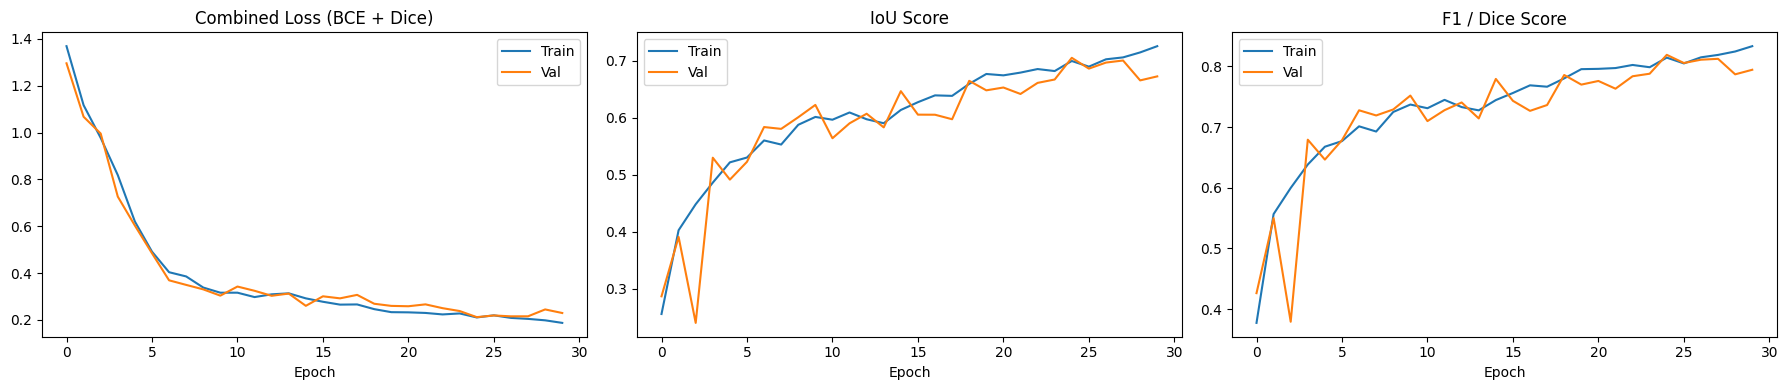

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history.history["loss"],     label="Train")
axes[0].plot(history.history["val_loss"], label="Val")
axes[0].set_title("Combined Loss (BCE + Dice)")
axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(history.history["iou"],      label="Train")
axes[1].plot(history.history["val_iou"],  label="Val")
axes[1].set_title("IoU Score")
axes[1].legend(); axes[1].set_xlabel("Epoch")

axes[2].plot(history.history["f1"],       label="Train")
axes[2].plot(history.history["val_f1"],   label="Val")
axes[2].set_title("F1 / Dice Score")
axes[2].legend(); axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

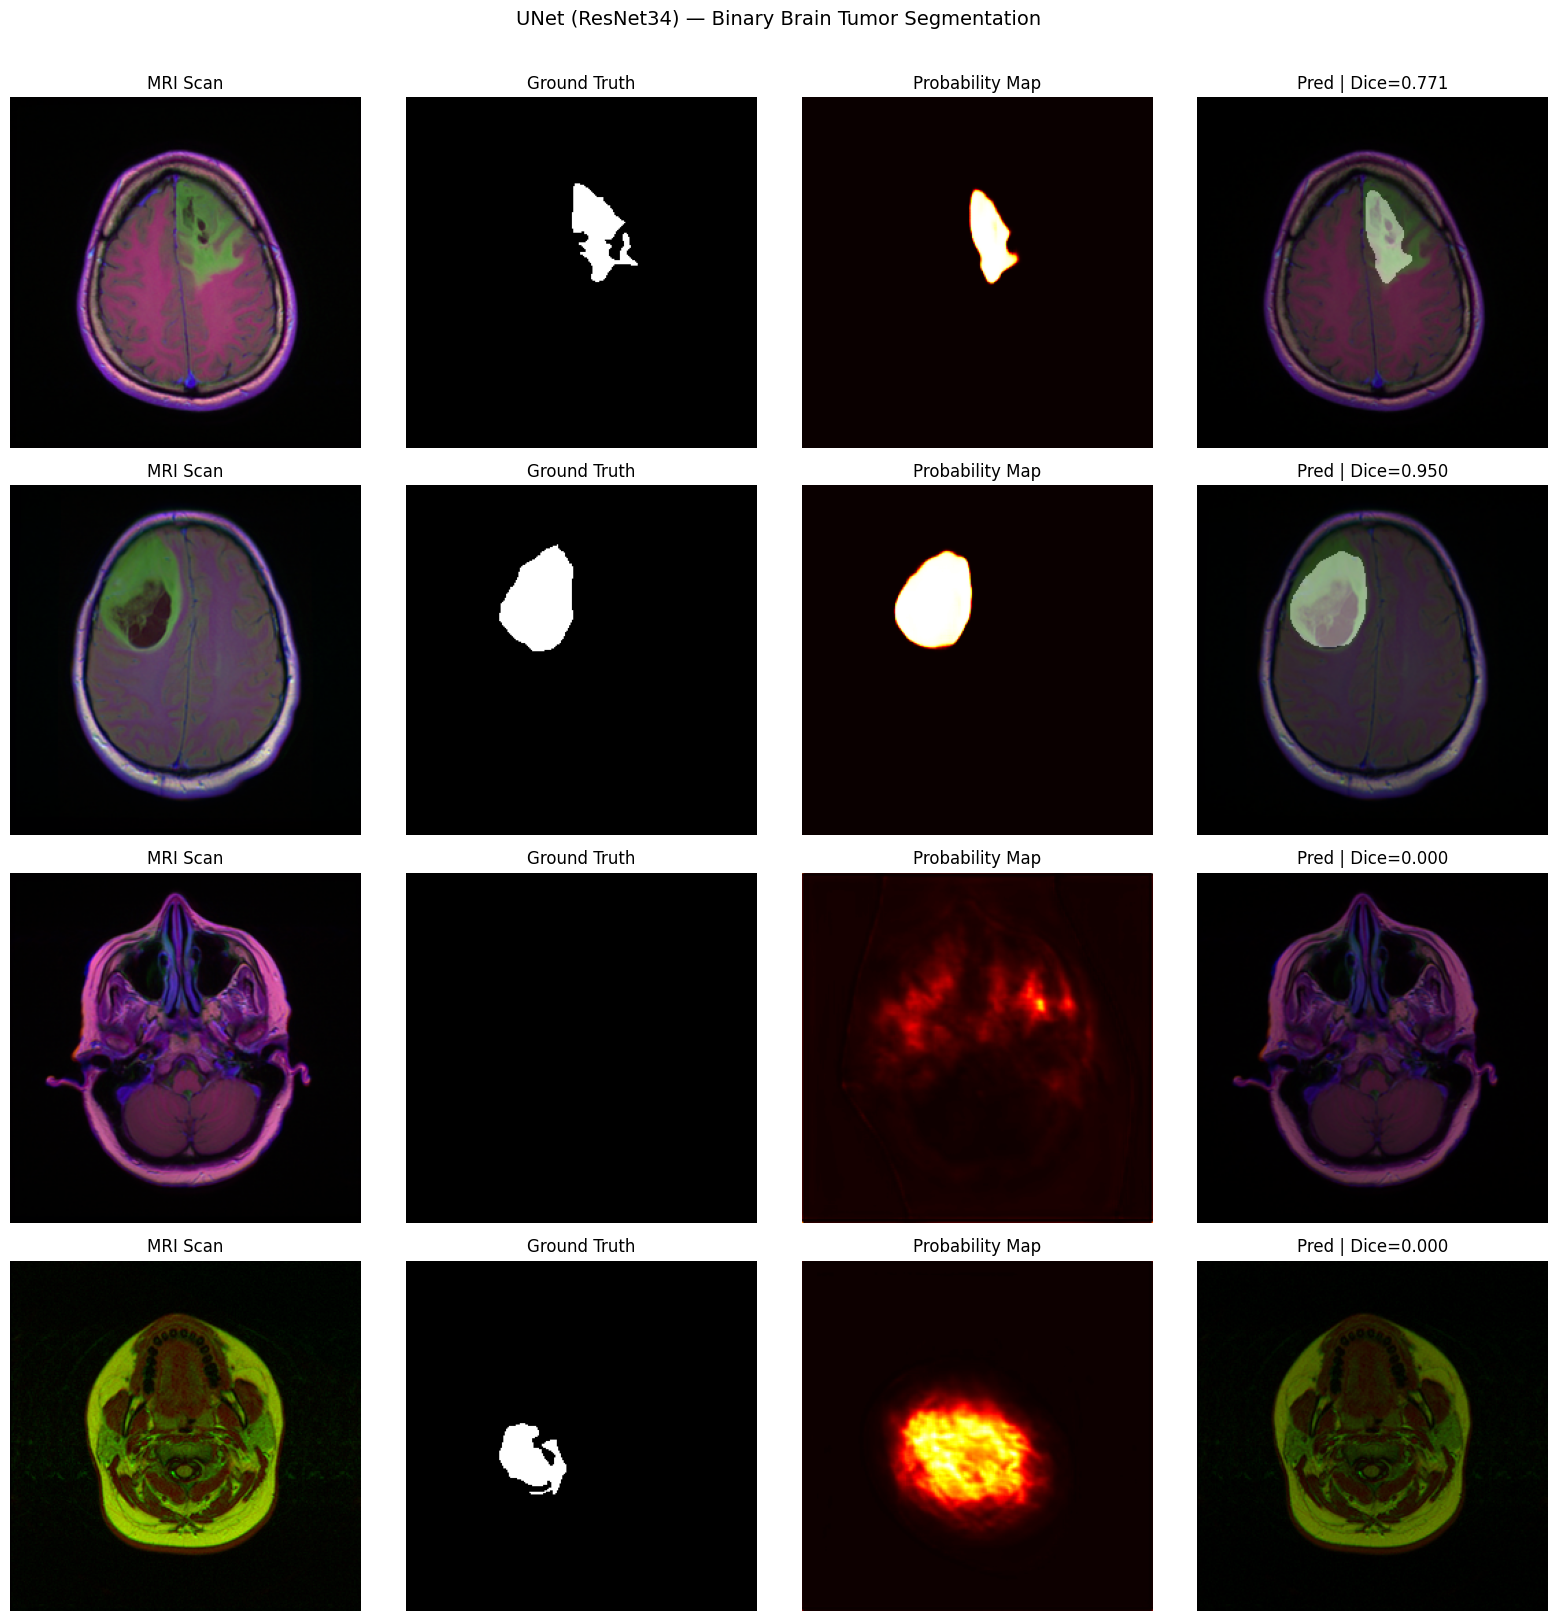

In [31]:
model.load_weights("best_unet_brain.keras")

imgs_batch, masks_batch = next(iter(val_ds))
preds     = model(imgs_batch, training=False)        # (B, H, W, 1) sigmoid probs
preds_bin = tf.cast(preds > 0.5, tf.float32)         # (B, H, W, 1) binary mask

def dice_score(pred, gt):
    pred  = tf.cast(pred > 0.5, tf.float32)
    inter = tf.reduce_sum(pred * gt)
    return (2.0 * inter / (tf.reduce_sum(pred) + tf.reduce_sum(gt) + 1e-8)).numpy()

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for i in range(4):
    dice     = dice_score(preds[i], masks_batch[i])
    prob_map = preds[i, :, :, 0].numpy()
    img = imgs_batch[i].numpy()
    img = img - img.min()
    img = img / img.max()
    mask = masks_batch[i,:,:,0].numpy()
    mask = mask - mask.min()
    #mask = mask / mask.max()
    overlay  = (
        img * 0.6 * 255 +
        np.stack([preds_bin[i, :, :, 0].numpy() * 255] * 3, axis=-1) * 0.4
    ).clip(0, 255).astype(np.uint8)

    axes[i,0].imshow(img);  axes[i,0].set_title("MRI Scan")
    axes[i,1].imshow(mask, cmap="gray");            axes[i,1].set_title("Ground Truth")
    axes[i,2].imshow(prob_map,             cmap="hot");             axes[i,2].set_title("Probability Map")
    axes[i,3].imshow(overlay);                                      axes[i,3].set_title(f"Pred | Dice={dice:.3f}")
    for ax in axes[i]: ax.axis("off")

plt.suptitle("UNet (ResNet34) — Binary Brain Tumor Segmentation", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("inference_output.png", dpi=150, bbox_inches="tight")
plt.show()

![](images/bmrs.gif)

### **9. 3D Segmentation of Liver CT images with Swin-UNETR**

In [ ]:
!pip install "monai[fire,nibabel,tqdm,einops]" torch matplotlib nibabel -q
!pip install connected-components-3d -q    # for 3D surface rendering
# ── Pretrained liver/organ segmentation bundle ────────────────────────────────
!python -m monai.bundle download "swin_unetr_btcv_segmentation" --bundle_dir bundles

In [ ]:
import os, glob, torch, numpy as np, nibabel as nib
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from monai.networks.nets import SwinUNETR
from monai.transforms import (
    EnsureChannelFirst, Orientation, Spacing,
    ScaleIntensityRange, EnsureType, Compose
)
from monai.inferers import sliding_window_inference
import inspect

# ── Config ────────────────────────────────────────────────────────────────────
INPUT_DIR  = "Task03_Liver/imagesTr"
OUTPUT_DIR = "images"
os.makedirs(OUTPUT_DIR, exist_ok=True)

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BUNDLE_DIR = "bundles/swin_unetr_btcv_segmentation"

LABELS = {0:"background",1:"spleen",2:"r.kidney",3:"l.kidney",4:"gallbladder",
          5:"esophagus",6:"liver",7:"stomach",8:"aorta",9:"inf.vena cava",
          10:"portal vein",11:"pancreas",12:"r.adrenal",13:"l.adrenal"}
COLORS = np.array([
    [0,  0,  0  ],[255,128,0  ],[255,0,  0  ],[0,  0,  255],[0,  255,0  ],
    [255,255,0  ],[210,105,30 ],[255,20, 147],[255,0,  255],[0,  255,255],
    [128,0,  128],[255,165,0  ],[0,  128,255],[255,69, 0  ]
], dtype=np.uint8)

# ── Load model once ───────────────────────────────────────────────────────────
sig         = inspect.signature(SwinUNETR.__init__)
base_kwargs = dict(in_channels=1, out_channels=14, feature_size=48, use_checkpoint=False)
if "img_size" in sig.parameters:
    base_kwargs["img_size"] = (96, 96, 96)

model = SwinUNETR(**base_kwargs).to(device)
ckpt  = torch.load(f"{BUNDLE_DIR}/models/model.pt", map_location=device)
model.load_state_dict({k.replace("module.",""): v for k,v in ckpt.items()}, strict=False)
model.eval()
print("Model loaded")

# ── Preprocessing + inference ─────────────────────────────────────────────────
preprocess = Compose([
    EnsureChannelFirst(channel_dim="no_channel"),
    Orientation(axcodes="RAS"),
    Spacing(pixdim=(1.5,1.5,2.0), mode="bilinear"),
    ScaleIntensityRange(a_min=-175, a_max=250, b_min=0., b_max=1., clip=True),
    EnsureType(),
])

def pad32(t):
    s = torch.tensor(t.shape[1:])
    p = ((32 - s % 32) % 32)
    return torch.nn.functional.pad(t,[0,int(p[2]),0,int(p[1]),0,int(p[0])]), tuple(s.tolist())

def run_inference(ct_path):
    nii    = nib.load(ct_path)
    img_t  = preprocess(nii.get_fdata().astype(np.float32))
    img_padded, orig_shape = pad32(img_t)
    with torch.no_grad():
        pred = sliding_window_inference(
            img_padded.unsqueeze(0).to(device),
            roi_size=(96,96,96), sw_batch_size=2, predictor=model, overlap=0.5
        )
    H,W,D = orig_shape
    seg = torch.softmax(pred,1).argmax(1).squeeze()[:H,:W,:D].cpu().numpy()
    return img_t.squeeze().cpu().numpy(), seg

# ── Visualization helpers ──────────────────────────────────────────────────────
def norm(x):     return (x-x.min())/(x.max()-x.min()+1e-8)
def colorize(s): return COLORS[np.clip(s, 0, len(COLORS)-1)]
def overlay(i,s,a=0.55):
    rgb=np.stack([norm(i)]*3,-1); col=colorize(s)/255.; out=rgb.copy()
    out[s>0]=rgb[s>0]*(1-a)+col[s>0]*a
    return (out*255).clip(0,255).astype(np.uint8)
def spotlight(i,s):
    base=np.stack([norm(i)]*3,-1); out=base*0.12
    mask=(s==6); out[mask]=base[mask]*0.25+np.array([0.82,0.41,0.12])*0.75
    return (out*255).clip(0,255).astype(np.uint8)

def plot_and_save(img, seg, ct_path):
    fname = os.path.basename(ct_path).replace(".nii.gz","").replace(".nii","")
    cz    = int(np.where(seg==6)[2].mean()) if np.any(seg==6) else seg.shape[2]//2
    im, sg = norm(img[:,:,cz]).T, seg[:,:,cz].T

    panels = [("CT Scan",        im,              "bone"),
              ("Segmentation",   colorize(sg),    None  ),
              ("Overlay",        overlay(im,sg),  None  ),
              ("Liver Spotlight",spotlight(im,sg),None  )]

    fig, axes = plt.subplots(1, 4, figsize=(22, 6),
                             gridspec_kw={"wspace":0.04},
                             facecolor="#0d0d0d")
    fig.suptitle(f"MONAI -> Swin-UNETR -> Axial Segmentation  ->  {fname}",
                 color="white", fontsize=13, fontweight="bold", y=1.01)

    for ax,(title,data,cmap) in zip(axes, panels):
        ax.imshow(data, cmap=cmap, origin="lower")
        ax.set_title(title, color="white", fontsize=10, pad=5)
        ax.set_facecolor("#0d0d0d"); ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_edgecolor("#333")

    detected = [i for i in np.unique(seg) if i > 0]
    patches  = [mpatches.Patch(color=COLORS[i]/255., label=LABELS[i].title())
                for i in detected]
    fig.legend(handles=patches, loc="lower center", ncol=len(patches),
               fontsize=8, frameon=True, facecolor="#1a1a1a",
               edgecolor="#444", labelcolor="white",
               bbox_to_anchor=(0.5, -0.08))

    out_path = os.path.join(OUTPUT_DIR, f"{fname}_axial.png")
    plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor="#0d0d0d")
    plt.close(fig)
    print(f"Saved:  {out_path}")

# ── Main loop ─────────────────────────────────────────────────────────────────
ct_files = sorted(glob.glob(os.path.join(INPUT_DIR,"**/*.nii*"), recursive=True))
print(f"Found {len(ct_files)} CT files\n{'='*45}")

ct_path = os.path.join(INPUT_DIR,"liver_3.nii.gz")
print(f"{os.path.basename(ct_path)}")
try:
    img, seg = run_inference(ct_path)
    print(f"organs: {[LABELS[i] for i in np.unique(seg) if i>0]}")
    plot_and_save(img, seg, ct_path)
except Exception as e:
    print(f"Failed: {e}")

print(f"\n Done - outputs in {OUTPUT_DIR}")

![](images/liver_3_axial.png)

In [ ]:
import numpy as np

LABELS = {0:"background",1:"spleen",2:"r.kidney",3:"l.kidney",4:"gallbladder",
          5:"esophagus",6:"liver",7:"stomach",8:"aorta",9:"inf.vena cava",
          10:"portal vein",11:"pancreas",12:"r.adrenal",13:"l.adrenal"}

COLORS = np.array([
    [0,0,0],[255,128,0],[255,0,0],[0,0,255],[0,255,0],
    [255,255,0],[210,105,30],[255,20,147],[255,0,255],[0,255,255],
    [128,0,128],[255,165,0],[0,128,255],[255,69,0]
], dtype=np.uint8)/255.0

#### **3D Visualization with `vedo`**

In [ ]:
from vedo import Volume, Mesh, LegendBox, Plotter
from skimage import measure

# --- create organ meshes ---
meshes = []

for label, name in LABELS.items():

    if label == 0:
        continue

    mask = seg == label
    if mask.sum() == 0:
        continue

    verts, faces, _, _ = measure.marching_cubes(mask, 0)

    mesh = Mesh([verts, faces])
    mesh.c(COLORS[label]).alpha(0.7)
    mesh.name = name

    meshes.append(mesh)

legend = LegendBox(meshes)

# --- CT volume ---
ct_vol = Volume(img)
ct_vol.cmap("bone")
ct_vol.alpha([0,0.1,0.2,0.4,0.8])

# --- create 2-panel viewer ---
plt = Plotter(N=2, axes=9, bg="black", size=(1600,800))

plt.show(ct_vol, at=0)           # left panel (CT)
plt.show(meshes, at=1)  # right panel (segmentation)
#plt.interactive().close()

![](images/vedo_seg_liver.png)

#### **3D Visualization with `vtk`**

In [ ]:
import vtk
import numpy as np
import imageio
from vtk.util import numpy_support
from skimage import measure

# -----------------------------
# Renderers
# -----------------------------

renderer1 = vtk.vtkRenderer()
renderer2 = vtk.vtkRenderer()

renderer1.SetViewport(0,0.15,0.5,1)
renderer2.SetViewport(0.5,0.15,1,1)

renderer1.SetBackground(0,0,0)
renderer2.SetBackground(0,0,0)

# -----------------------------
# CT volume
# -----------------------------

data = numpy_support.numpy_to_vtk(img.ravel(order="F"), deep=True)

ct = vtk.vtkImageData()
ct.SetDimensions(img.shape)
ct.GetPointData().SetScalars(data)

mapper = vtk.vtkSmartVolumeMapper()
mapper.SetInputData(ct)

color = vtk.vtkColorTransferFunction()
color.AddRGBPoint(-1000,0,0,0)
color.AddRGBPoint(-300,0.7,0.7,0.7)
color.AddRGBPoint(40,1.0,0.8,0.7)
color.AddRGBPoint(400,1,1,1)

opacity = vtk.vtkPiecewiseFunction()
opacity.AddPoint(-1000,0)
opacity.AddPoint(-300,0)
opacity.AddPoint(40,0.15)
opacity.AddPoint(200,0.3)
opacity.AddPoint(1000,0.85)

volumeProperty = vtk.vtkVolumeProperty()
volumeProperty.SetColor(color)
volumeProperty.SetScalarOpacity(opacity)
volumeProperty.ShadeOn()
volumeProperty.SetInterpolationTypeToLinear()

volume = vtk.vtkVolume()
volume.SetMapper(mapper)
volume.SetProperty(volumeProperty)

renderer1.AddVolume(volume)

# -----------------------------
# segmentation meshes
# -----------------------------

actors = []

for label, name in LABELS.items():

    if label == 0:
        continue

    mask = seg == label
    if mask.sum() == 0:
        continue

    verts, faces, _, _ = measure.marching_cubes(mask,0)

    points = vtk.vtkPoints()
    for v in verts:
        points.InsertNextPoint(v)

    triangles = vtk.vtkCellArray()

    for f in faces:
        tri = vtk.vtkTriangle()
        tri.GetPointIds().SetId(0,f[0])
        tri.GetPointIds().SetId(1,f[1])
        tri.GetPointIds().SetId(2,f[2])
        triangles.InsertNextCell(tri)

    poly = vtk.vtkPolyData()
    poly.SetPoints(points)
    poly.SetPolys(triangles)

    mapper = vtk.vtkPolyDataMapper()
    mapper.SetInputData(poly)

    actor = vtk.vtkActor()
    actor.SetMapper(mapper)
    actor.GetProperty().SetColor(*COLORS[label])
    actor.GetProperty().SetOpacity(0.8)

    renderer2.AddActor(actor)
    actors.append(actor)

renderer1.ResetCamera()
renderer2.ResetCamera()

# -----------------------------
# Shared camera
# -----------------------------

camera = renderer1.GetActiveCamera()
renderer2.SetActiveCamera(camera)

# -----------------------------
# Title
# -----------------------------

title = vtk.vtkTextActor()
title.SetInput("3D CT Volume and Organ Segmentation")

titleprop = title.GetTextProperty()
titleprop.SetFontSize(36)
titleprop.BoldOn()
titleprop.SetColor(1,1,1)

title.SetPosition(350,550)

# -----------------------------
# Segmentation legend (bottom)
# -----------------------------

legend = vtk.vtkLegendBoxActor()
legend.SetNumberOfEntries(len(LABELS)-1)

textProp = vtk.vtkTextProperty()
textProp.SetFontSize(32)
textProp.SetColor(1,1,1)
textProp.BoldOn()
legend.SetEntryTextProperty(textProp)

entry = 0

for label, name in LABELS.items():

    if label == 0:
        continue

    cube = vtk.vtkCubeSource()
    cube.Update()

    legend.SetEntry(entry, cube.GetOutput(), name, COLORS[label])
    entry += 1

legend.GetPositionCoordinate().SetCoordinateSystemToNormalizedViewport()
legend.GetPositionCoordinate().SetValue(0.25,0.02)
legend.GetPosition2Coordinate().SetValue(0.5,0.1)

legend.UseBackgroundOn()
legend.SetBackgroundColor(0,0,0)
legend.SetBackgroundOpacity(0.6)

# -----------------------------
# Render window
# -----------------------------

window = vtk.vtkRenderWindow()
window.SetSize(1200,600)
window.AddRenderer(renderer1)
window.AddRenderer(renderer2)

renderer1.AddActor2D(title)
renderer2.AddActor2D(legend)

window.Render()

# -----------------------------
# Capture frames
# -----------------------------

w2if = vtk.vtkWindowToImageFilter()
w2if.SetInput(window)
w2if.SetScale(1)
w2if.SetInputBufferTypeToRGB()
w2if.ReadFrontBufferOff()

frames = []

for i in range(180):

    camera.Azimuth(2)
    window.Render()

    w2if.Modified()
    w2if.Update()

    vtk_image = w2if.GetOutput()

    width, height, _ = vtk_image.GetDimensions()

    vtk_array = vtk_image.GetPointData().GetScalars()
    arr = numpy_support.vtk_to_numpy(vtk_array)

    arr = arr.reshape(height, width, 3)
    arr = np.flipud(arr)

    frames.append(arr)

# -----------------------------
# Save GIF
# -----------------------------

imageio.mimsave("ct_segmentation_rotation.gif", frames, duration=0.05)

print("GIF saved as ct_segmentation_rotation.gif")

![](images/vtk_seg_liver.png)
![](images/vtk_seg_liver.gif)

### **9. Remote Sensing: Multi-Source Satellite Imagery Segmentation with Mixed-Attention UNet**

In [ ]:
# run on GPU / in colab
#!pip install kaggle
import kagglehub
import os 

# download datasetA
os.environ["KAGGLEHUB_CACHE"] = "."

# Download latest version
path = kagglehub.dataset_download("hammadjavaid/multi-source-satellite-imagery-for-segmentation") 
print("Path to dataset files:", path)
# .\datasets\hammadjavaid\multi-source-satellite-imagery-for-segmentation\versions\1

#!mkdir data
#!mv ./datasets/hammadjavaid/multi-source-satellite-imagery-for-segmentation/versions/1/all/* data

In [ ]:
import cv2
import glob
import numpy as np
import torch
import matplotlib.pyplot as plt
import albumentations as A
from torch.utils.data import Dataset,DataLoader
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import torch.nn.functional as F

PATCH=512

def extract_patches(img,mask):

    H,W,_ = img.shape
    patches=[]

    for y in range(0,H-PATCH,PATCH):
        for x in range(0,W-PATCH,PATCH):
            im = img[y:y+PATCH,x:x+PATCH]
            m  = mask[y:y+PATCH,x:x+PATCH]            
            patches.append((im,m))
            #mask_pixels = np.count_nonzero(m)
            #if mask_pixels > 20: #200:
                #patches.append((im,m))
                #patches.append((im,m))
                #patches.append((im,m))
            #else:
            #    if np.random.rand() < 0.05:
            #        patches.append((im,m))
            #water_mask = (m[:,:,0]==226) & (m[:,:,1]==169) & (m[:,:,2]==41)
            #water_pixels = water_mask.sum()
            
            #if water_pixels > 50:
                #patches.append((im,m))
                #patches.append((im,m))
                #patches.append((im,m))
                
    return patches

data=[]

imgs=sorted(glob.glob("data/images/*"))
masks=sorted(glob.glob("data/masks/*"))

for i in range(len(imgs)):
    img=cv2.imread(imgs[i])
    #print(masks[i])
    mask=cv2.imread(masks[i])
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    mask=cv2.cvtColor(mask,cv2.COLOR_BGR2RGB)
    data+=extract_patches(img,mask)

print("Total patches:",len(data))
# Total patches: 5318

np.random.shuffle(data)
colors=set()
for _,m in data[:50]:
    u=np.unique(m.reshape(-1,3),axis=0)
    for c in u:
        colors.add(tuple(c))

colors=sorted(colors)
COLOR_MAP={c:i for i,c in enumerate(colors)}
NUM_CLASSES=len(COLOR_MAP)
print("Classes:",NUM_CLASSES)
# Classes: 7

device="cuda" if torch.cuda.is_available() else "cpu"
device
# cuda

def encode_mask(mask):
    h,w,_ = mask.shape
    label = np.zeros((h,w),dtype=np.int64)
    for c,i in COLOR_MAP.items():
        label[(mask==c).all(axis=-1)] = i
    return label

# ---- compute class frequencies ----
class_counts = np.zeros(NUM_CLASSES)

for _,m in data:
    lbl = encode_mask(m)
    u,c = np.unique(lbl, return_counts=True)
    for i,j in zip(u,c):
        class_counts[i] += j

# print("Pixel distribution:",class_counts)

freq = class_counts / class_counts.sum()
median = np.median(freq)
class_weights = median / (freq + 1e-6)
class_weights = torch.tensor(class_weights,dtype=torch.float32)
#water_class = 5
#class_weights[water_class] *= 3

print("Class weights:",class_weights)
# Class weights: tensor([ 1.0000,  0.2587, 13.6788,  0.2129,  3.9385,  9.6320,  0.1739])

class_weights = class_weights.to(device)

aug=A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(),
    A.RandomBrightnessContrast(p=0.3),
    ToTensorV2()
])

def dice_loss(pred,gt):
    pred=torch.softmax(pred,dim=1)
    gt_onehot=F.one_hot(gt,NUM_CLASSES).permute(0,3,1,2).float()
    inter=(pred*gt_onehot).sum((2,3))
    union=pred.sum((2,3))+gt_onehot.sum((2,3))
    dice=(2*inter+1e-6)/(union+1e-6)
    return 1-dice.mean()

In [ ]:
class PatchDataset(Dataset):

    def __len__(self):
        return len(data)

    def __getitem__(self, i):

      img, mask = data[i]
      # skip broken patches
      if img is None or mask is None:
          return self.__getitem__((i + 1) % len(data))
      if img.size == 0 or mask.size == 0:
          return self.__getitem__((i + 1) % len(data))
      mask = encode_mask(mask)
      # ensure mask size matches image
      if mask.shape[:2] != img.shape[:2]:
          mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
      out = aug(image=img, mask=mask)
      img = out["image"].float()
      img = img / img.max()
      mask = out["mask"].long()
      return img, mask

ds=PatchDataset()
loader=DataLoader(
    ds,
    batch_size=8,
    shuffle=True,
    #num_workers=2
)

#model=smp.DeepLabV3Plus(
#    encoder_name="resnet34",
#    encoder_weights="imagenet",
#    classes=NUM_CLASSES,
#    activation=None
#).to(device)

model = smp.MAnet("resnet34",encoder_weights="imagenet",classes=NUM_CLASSES,
    activation=None).to(device)    # Attention-like

opt=torch.optim.AdamW(model.parameters(),lr=1e-3)
scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    factor=0.5,
    patience=2
)

for epoch in range(10):
    model.train()
    total_loss = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        opt.zero_grad()
        pred = model(x)
        loss = 0.5*F.cross_entropy(pred, y, weight=class_weights) + 0.5*dice_loss(pred, y)   
        #ce = F.cross_entropy(pred,y) #,weight=class_weights)
        #loss = 0.5*ce*(1-torch.exp(-ce))**2 + 0.5*dice_loss(pred,y) # focal loss + dice loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0) # prevent exploding gradient
        opt.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    scheduler.step(avg_loss)
    print("Epoch", epoch, "Loss", avg_loss)

# Epoch 0 Loss 0.9757289691078932
# Epoch 1 Loss 0.8429152606125164
# Epoch 2 Loss 0.8089287074436818
# Epoch 3 Loss 0.7485824577790454
# Epoch 4 Loss 0.7199158089053362
# Epoch 5 Loss 0.7097915019755973
# Epoch 6 Loss 0.6810934002238108
# Epoch 7 Loss 0.6643141189464052
# Epoch 8 Loss 0.6605846921304115
# Epoch 9 Loss 0.637118750452099

torch.save({
    "model": model.state_dict(),
    "optimizer": opt.state_dict(),
    "epoch": epoch
}, "checkpoint_MAUNet_20.pth")

In [ ]:
def dice_score(pred,gt):
  inter=(pred==gt).sum()
  return (2*inter)/(pred.size+gt.size)

def decode_mask(label_mask):
    h,w = label_mask.shape
    rgb = np.zeros((h,w,3),dtype=np.uint8)
    for i,color in INDEX_TO_COLOR.items():
        rgb[label_mask==i] = color
    return rgb

model.eval()

i = 0 # change this
img,gt=ds[i]
img = img / img.max()    
with torch.no_grad():
    pred=model(img.unsqueeze(0).to(device))

pred=torch.argmax(pred,1).squeeze().cpu().numpy()
gt=gt.numpy()

INDEX_TO_COLOR = {v:k for k,v in COLOR_MAP.items()}
pred_rgb = decode_mask(pred)
gt_rgb   = decode_mask(gt)

dice=dice_score(pred,gt)

plt.figure(figsize=(11,4))
plt.subplot(131)
plt.title("Image")
plt.imshow(img.permute(1,2,0))
plt.subplot(132)
plt.title("Ground Truth")
plt.imshow(gt_rgb)
plt.subplot(133)
plt.title(f"Prediction Dice={dice:.3f}")
plt.imshow(pred_rgb)
plt.tight_layout()
plt.show()

![](images/sus.gif)

In [ ]:
def compute_dice(pred, gt, num_classes):

    dice_scores=[]

    for c in range(num_classes):

        pred_c = (pred==c)
        gt_c   = (gt==c)

        inter = np.logical_and(pred_c,gt_c).sum()
        union = pred_c.sum()+gt_c.sum()

        if union==0:
            dice=1.0
        else:
            dice=(2*inter)/(union)

        dice_scores.append(dice)
    print(dice_scores)
    return np.mean(dice_scores)


i = 1

img_path, mask_path = imgs[i], masks[i]
img  = cv2.imread(img_path)
mask = cv2.imread(mask_path)

img  = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
mask = cv2.cvtColor(mask,cv2.COLOR_BGR2RGB)
#print(img.shape, mask.shape)
H,W,_ = img.shape

# ---- pad image to multiple of PATCH ----
pad_h = (PATCH - H % PATCH) % PATCH
pad_w = (PATCH - W % PATCH) % PATCH

img_pad = np.pad(img,((0,pad_h),(0,pad_w),(0,0)),mode='reflect')
mask_pad = np.pad(mask,((0,pad_h),(0,pad_w),(0,0)),mode='reflect')

Hp,Wp,_ = img_pad.shape

pred_full = np.zeros((Hp,Wp),dtype=np.uint8)

for y in range(0,Hp,PATCH):
    for x in range(0,Wp,PATCH):

        patch = img_pad[y:y+PATCH,x:x+PATCH]

        inp = torch.tensor(patch).permute(2,0,1).float()
        inp = inp / inp.max()
        inp = inp.unsqueeze(0).to(device)

        with torch.no_grad():
            out = model(inp)

        pred = torch.argmax(out,1).squeeze().cpu().numpy()
        gt = encode_mask(mask_pad[y:y+PATCH,x:x+PATCH])
        pred_rgb = decode_mask(pred)
        gt_rgb   = decode_mask(gt)
        #plt.imshow(np.hstack((img_pad[y:y+PATCH,x:x+PATCH], gt_rgb, pred_rgb))); plt.show()

        pred_full[y:y+PATCH,x:x+PATCH] = pred

# ---- crop back to original size ----
pred_full = pred_full[:H,:W]

gt = encode_mask(mask)
dice = compute_dice(pred_full, gt, NUM_CLASSES)
print("Dice Score:",dice)

gt = encode_mask(mask)

pred_rgb = decode_mask(pred_full)
gt_rgb   = decode_mask(gt)

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(gt_rgb)
plt.axis("off")

plt.subplot(1,3,3)
plt.title(f"Prediction | Dice={dice:.3f}")
plt.imshow(pred_rgb)
plt.axis("off")

plt.tight_layout()
plt.show()

![](images/sus_out.png)

### **11. Segmentation Evaluation Metrics**

## Further reading

1. http://scikit-image.org/docs/dev/user_guide/tutorial_segmentation.html
2. https://www.scipy-lectures.org/packages/scikit-image/index.html
3. http://scikit-image.org/docs/dev/auto_examples/
4. https://web.stanford.edu/class/ee368/Handouts/Lectures/2014_Spring/Combined_Slides/6-Image-Segmentation-Combined.pdf
5. https://courses.csail.mit.edu/6.869/lectnotes/lect19/lect19-slides-6up.pdf
6. http://cmm.ensmp.fr/~beucher/publi/WTS_residues.pdf
7. http://cmm.ensmp.fr/~beucher/wtshed.html
8. https://sandipanweb.wordpress.com/2018/02/25/graph-based-imagesegmentation-in-python/
9. https://sandipanweb.wordpress.com/2018/02/11/interactive-imagesegmentation-with-graph-cut/
10. http://people.cs.uchicago.edu/~pff/papers/seg-ijcv.pdf
11. http://www.kev-smith.com/papers/SMITH_TPAMI12.pdf
12. https://youtu.be/RL4VxB-Vjhs